# Local-Offline-RAG

This notebook only exercises the disconnected path. It uses held-out query photos that are not indexed, local image captioning, local CLIP image/text/caption embeddings, a local SQLite vector store, and Phi-4-mini ONNX CPU/mobile for grounded answer drafting.

**Downstream selection for Hybrid-RAG:** Use BLIP as the fast A10 VM baseline, but select Moondream for the target iOS Hybrid-RAG architecture under the Core ML / MLX optimization assumption.


## Offline execution path

```mermaid
flowchart TD
  Q["Held-out worker photo and question"] --> C["Local visual caption"]
  Q --> E["CLIP image embedding"]
  C --> T["CLIP text and caption embedding"]
  E --> F["Fused query vector"]
  T --> F
  F --> S["SQLite local vector store"]
  S --> R["Top cited historical cases"]
  R --> P["Evidence prompt"]
  P --> Phi["Phi-4-mini ONNX CPU mobile"]
  Phi --> A["Grounded field response"]
```


## Clean report locations

| Artifact | Path |
| --- | --- |
| BLIP + Phi-4-mini report | `notebooks/reports/local_offline_rag/blip_phi4_report.json` |
| Moondream + Phi-4-mini report | `notebooks/reports/local_offline_rag/moondream_phi4_report.json` |
| Held-out query manifest | `notebooks/reports/local_offline_rag/heldout_query_images.json` |
| Query image folder | `notebooks/assets/real_local_inference/query_images/` |
| Indexed case image folder | `notebooks/assets/cv_rag_enriched/images/` |


## What is available offline

The local vector store indexes six enriched seed incidents. The held-out query photos are separate and are not indexed.

| ID | Severity | Category | Why it belongs in the offline pack |
| --- | --- | --- | --- |
| INC-001 | high | Waterproofing / Basement Envelope | Retain as an offline seed because basement waterproofing defects are frequent, image-recognizable, and useful for baseline retrieval without internet dependency. |
| INC-002 | high | Concrete Quality / Structural Defect | Retain as an offline seed because concrete quality defects are core CV-RAG examples with stable visual characteristics and common inspection language. |
| INC-003 | medium | Reinforcement / Buildability | Retain as an offline seed because reinforcement congestion is a repeatable pre-pour condition that benefits from cached visual exemplars and checklist guidance. |
| INC-004 | medium | MEP Coordination / Clashes | Retain as an offline seed because MEP clashes are common in visual QA workflows and useful for training cross-trade reasoning in a disconnected environment. |
| INC-005 | critical | Fall Protection / Working at Height | Retain as an offline seed because open-edge fall hazards are high-value safety examples and visually obvious for CV-RAG detection even without live connectivity. |
| INC-006 | medium | Structural Observation / Crack Monitoring | Retain as an offline seed because crack monitoring is a common inspection scenario and supports visual differentiation between benign and potentially structural defects. |


Indexed offline case pack 
 
 INC-001 - Basement wall water ingress observed at construction joint Severity: high | Waterproofing / Basement Envelope 
 INC-002 - Concrete column honeycombing detected after form removal Severity: high | Concrete Quality / Structural Defect 
 INC-003 - Rebar congestion visible at beam-column joint Severity: medium | Reinforcement / Buildability 
 INC-004 - MEP duct coordination clash at ceiling void Severity: medium | MEP Coordination / Clashes 
 INC-005 - Unsafe open edge adjacent to scaffold access point Severity: critical | Fall Protection / Working at Height 
 INC-006 - Hairline crack observed near lift core wall opening Severity: medium | Structural Observation / Crack Monitoring
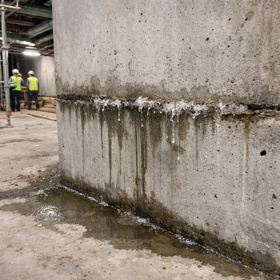
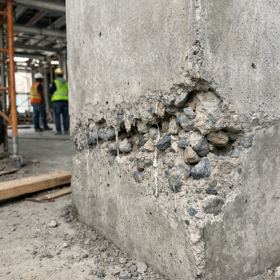
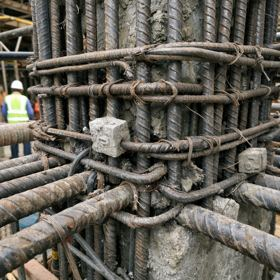
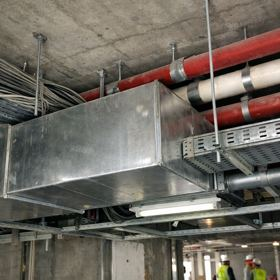
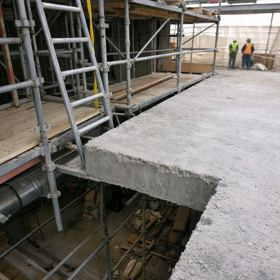
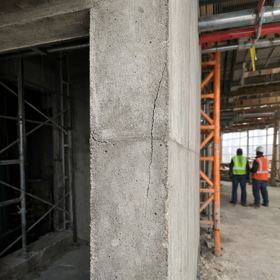

In [1]:
from IPython.display import HTML, display
display(HTML(indexed_offline_cases_html))


## BLIP vs Moondream: semantic and retrieval comparison

Both captioners were evaluated against the same four held-out field photos. BLIP is the fast operational baseline on the A10 VM. Moondream2 provides richer semantics, but it did not fit on the 4 GB A10-4Q CUDA profile and used CPU.

| Scenario | BLIP caption | Moondream caption | BLIP top hit | Moondream top hit | Caption latency |
| --- | --- | --- | --- | --- | --- |
| Held-out basement water ingress field photo | a construction site photo of a concrete wall | A construction-site issue visible is a large puddle of water on the ground near a concrete wall.  The water appears to be leaking from the wall, potentially due to structural damage or water intrusion. The field conditi... | INC-001 (0.8561) | INC-001 (0.8604) | BLIP 0.249s / Moondream 221.8s |
| Held-out concrete column honeycombing field photo | a construction site photo of a concrete wall | A damaged concrete pillar reveals a crack and exposed rebar, indicative of ongoing construction or repair work. The site appears dusty and unfinished, suggesting poor workmanship or inadequate maintenance. | INC-002 (0.8443) | INC-002 (0.8531) | BLIP 0.137s / Moondream 220.8s |
| Held-out scaffold edge protection field photo | a construction site photo of a construction site | A hole in the concrete surface is visible, likely caused by excavation work.  The site appears unfinished and under construction, with exposed metal scaffolding and exposed concrete. | INC-005 (0.8299) | INC-005 (0.8029) | BLIP 0.125s / Moondream 220.0s |
| Held-out rebar congestion field photo | a construction site photo of a pile of old metal pipes | A construction-site issue visible in the image is the exposed rebar, which appears rusted and corroded. This defect poses a safety hazard, as rusted rebar can weaken the structure or cause it to collapse. Considering th... | INC-003 (0.8260) | INC-003 (0.8531) | BLIP 0.162s / Moondream 224.4s |


BLIP caption,Moondream caption
a construction site photo of a concrete wall,"A construction-site issue visible is a large puddle of water on the ground near a concrete wall. The water appears to be leaking from the wall, potentially due to structural damage or water intrusion. The field condition appears to be damp and possibly wet."
BLIP caption,Moondream caption
a construction site photo of a concrete wall,"A damaged concrete pillar reveals a crack and exposed rebar, indicative of ongoing construction or repair work. The site appears dusty and unfinished, suggesting poor workmanship or inadequate maintenance."
BLIP caption,Moondream caption
a construction site photo of a construction site,"A hole in the concrete surface is visible, likely caused by excavation work. The site appears unfinished and under construction, with exposed metal scaffolding and exposed concrete."
BLIP caption,Moondream caption
a construction site photo of a pile of old metal pipes,"A construction-site issue visible in the image is the exposed rebar, which appears rusted and corroded. This defect poses a safety hazard, as rusted rebar can weaken the structure or cause it to collapse. Considering the site's wooden frame and wooden planks, the field condition appears to be relatively new or recently constructed."

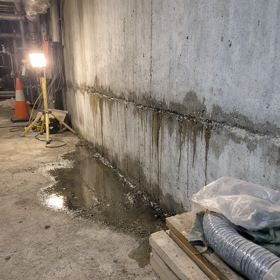
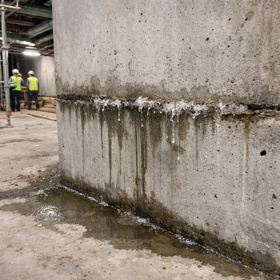
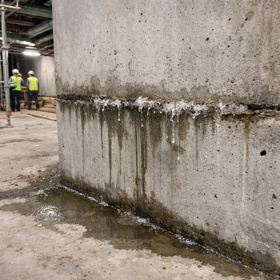
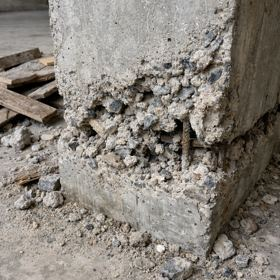
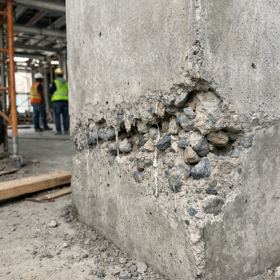
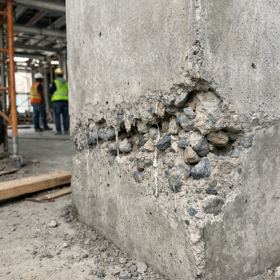
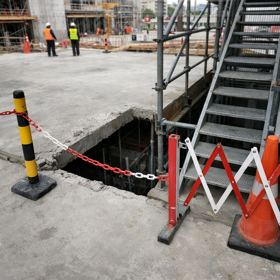
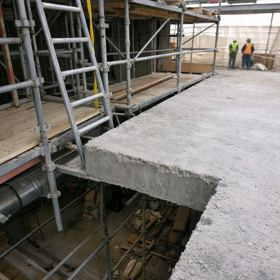
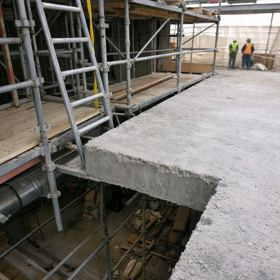
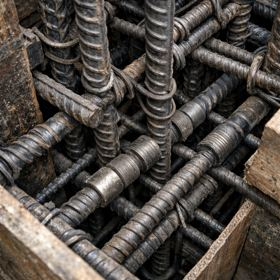
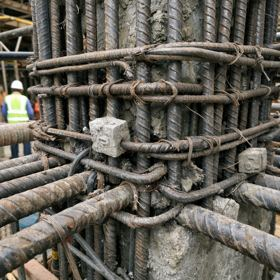
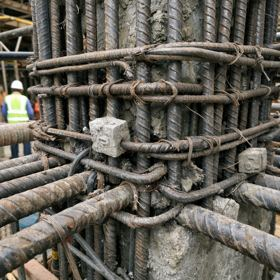

In [2]:
from IPython.display import HTML, display
display(HTML(offline_query_comparison_html))


## Phi-4-mini grounded answers

Phi-4-mini-instruct is text-only: it receives the retrieved case evidence and the local caption as text. The responses below are generated by Phi-4-mini ONNX CPU/mobile from local evidence only.

### Held-out basement water ingress field photo

**User question:** A new site photo shows active water seepage and damp staining along a basement retaining wall construction joint. What previous case is most relevant and what should we do next?

**BLIP + Phi-4-mini answer:**

> The most relevant incident ID for the situation described by the worker is INC-001. Based on the evidence retrieved from this incident, the following actions should be taken next:
> 1. Mark and photograph the full extent of the seepage and damp staining along the basement retaining wall construction joint. This step is crucial to document the severity and extent of the water ingress issue.
> 2. Inspect the joint detailing and check for membrane continuity and any penetrations or tieshoe repairs. This inspection can help identify the root cause of the water ingress, which is likely to be a compromised waterproofing detail or joint seal failure.
> 3. Examine adjacent drainage and sump operations to ensure they are functioning correctly and not contributing to the problem.
> 4. Implement temporary water control measures to mitigate the immediate risk and isolate any affected electrical or finish-sensitive areas.
> 5. Prepare a corrective action for a waterproofing specialist review and retesting after the repair to ensure the integrity of the waterproofing system.
> If the leakage increases, reaches active electrical equipment, or shows signs of wall movement, cracking, or soil washout, escalati...

**Moondream + Phi-4-mini answer:**

> The most relevant incident ID for the situation described by the worker is INC-001. Based on the evidence retrieved from this incident, the following actions should be taken next:
> 1. Mark and photograph the full extent of the seepage and damp staining along the basement retaining wall construction joint. This step is crucial to document the severity and extent of the water ingress issue accurately.
> 2. Inspect the joint detailing and check for any discontinuities in the waterproofing membrane. It's important to assess the integrity of the joint seal and the waterproofing system to identify the root cause of the water ingress.
> 3. Evaluate the adjacent drainage and sump operation to ensure they are functioning correctly and not contributing to the problem.
> 4. Implement temporary water control measures to mitigate the immediate risk and isolate any affected electrical or finish-sensitive areas to prevent damage.
> 5. Prepare a corrective action plan for a waterproofing specialist review and retesting after the repair work is completed to ensure the problem is fully resolved.
> If the leakage increases, reaches active electrical equipment, or shows signs of wall movement, cracking, or soil...

### Held-out concrete column honeycombing field photo

**User question:** A newly stripped concrete column face has honeycombing, exposed aggregate, and rough voids near the lower lift. Which previous case matches and what action is required?

**BLIP + Phi-4-mini answer:**

> The situation you've described matches incident ID INC-002. Here is the action required based on the retrieved evidence:
> 1. Sound the affected area and carry out a depth assessment by engineer or competent inspector. This step is crucial to determine the extent of the honeycombing and assess the impact on the structural integrity of the column.
> 2. Verify the reinforcement cover and determine whether structural repair is required. Honeycombing can compromise the integrity of the concrete and the protective layer of reinforcement. It's important to check if the honeycombing has penetrated deeply enough to affect the structural elements.
> 3. Review the pour sequence, vibration records, and formwork tightness for the affected lift. Honeycombing can occur due to inadequate vibration, congestion of reinforcement impeding flow, or grout loss through formwork joints. Reviewing the records can help identify the root cause and prevent recurrence.
> 4. Protect the area from impact and restrict loading until the disposition is confirmed. This is to ensure that the area is not compromised further and that the integrity of the column is maintained until a repair method is determined.
> 5. Prepare a...

**Moondream + Phi-4-mini answer:**

> The situation you've described matches incident ID INC-002. The severity of the honeycombing in the concrete column is high, and the presence of exposed aggregate and rough voids indicates a significant defect that requires immediate attention.
> The action required, as per the evidence from INC-002, includes the following steps:
> 1. Sound the affected area to halt any further work until the issue is assessed.
> 2. Carry out a depth assessment by an engineer or competent inspector to determine the extent of the honeycombing and its impact on the structural integrity.
> 3. Verify the reinforcement cover to assess if structural repair is necessary.
> 4. Review the pour sequence, vibration records, and formwork tightness for the affected lift to identify the root cause.
> 5. Protect the area from impact and restrict loading until the disposition is confirmed.
> 6. Prepare a repair method statement if repair options such as patching, epoxy injection, or breakout and reinstatement are needed.
> 7. Escalate to a structural engineer immediately if the defect depth approaches the reinforcement, cover is compromised, or if similar defects are observed in multiple columns.
> Please follow the escalation rul...

### Held-out scaffold edge protection field photo

**User question:** A field photo shows an open slab edge beside scaffold access with incomplete guardrails and a fall exposure. What similar case should we use and what immediate controls are needed?

**BLIP + Phi-4-mini answer:**

> The situation you've described matches incident ID INC-005. This incident involved an unsafe open edge adjacent to scaffold access, which created a critical fall exposure for workers. The immediate controls recommended in the evidence include:
> 1. Stop access to the affected route until edge protection is installed or alternative safe access is provided.
> 2. Install compliant guardrails, toe boards, and controlled access measures at the perimeter.
> 3. Inspect scaffold tie-ins, landing condition, and opening protections for related defects.
> 4. Brief all nearby crews on the exclusion and safe access route.
> 5. Record the hazard in the permit or daily safety log and verify closure before restart.
> 6. Escalate immediately to site management and safety leadership; work in the area must remain stopped until the fall hazard is fully controlled.
> Please follow these actions to ensure the safety of the workers and compliance with safety regulations. Do not attempt to provide access to the area until the hazard has been fully mitigated. If the hazard cannot be immediately corrected, escalate the situation to the appropriate level of authority as per your escalation policy.

**Moondream + Phi-4-mini answer:**

> Based on the evidence retrieved, the situation you've described matches incident ID INC-005. This incident involves an unsafe open edge adjacent to scaffold access, which has not been adequately protected by guardrails, presenting a critical fall exposure risk.
> The immediate controls needed, as per the evidence from INC-005, are as follows:
> 1. Stop access to the affected route immediately until edge protection is installed or an alternative safe access route is provided. This is to prevent any potential accidents while the hazard is not mitigated.
> 2. Install compliant guardrails, toe boards, and controlled access measures at the perimeter of the scaffold to provide the necessary fall protection.
> 3. Inspect scaffold ties, landings, and opening protections for related defects that may contribute to the hazard.
> 4. Brief all nearby crews on the exclusion and the establishment of a safe access route to ensure everyone is aware of the hazard and the measures taken to mitigate it.
> 5. Record the hazard in the permit or daily safety log and verify closure before restart to ensure the hazard has been adequately addressed.
> 6. Escalate immediately to site management and safety leadership to e...

### Held-out rebar congestion field photo

**User question:** The photo shows congested reinforcement at a beam-column joint before concrete pour, with tight bar spacing and limited access for vibration. What previous case applies and what should be checked?

**BLIP + Phi-4-mini answer:**

> The photo you've described matches the incident ID INC-003. Based on the retrieved evidence, here is what you should check:
> 1. Compare the installed reinforcement against the approved shop drawings and bar bending schedules to ensure compliance with the design intent (Action from INC-003).
> 2. Confirm that the minimum clear spacing, lap locations, and cover compliance are met before proceeding with the concrete pour (Action from INC-003).
> 3. Coordinate with the structural designer regarding any permissible bar adjustments or coupler alternatives that may be needed (Action from INC-003).
> 4. Plan the concrete placement carefully, considering the use of smaller aggregate, controlled lift heights, and ensuring dedicated vibration access (Action from INC-003).
> 5. Document the joint with pre-pour photos and obtain sign-off before closing forms (Action from INC-003).
> If you encounter situations where the clear spacing cannot be achieved, cover blocks cannot be installed correctly, or the pour is proceeding without engineer approval, you must escalate the issue according to the escalation rules provided in the evidence (Escalation from INC-003).
> Ensure that you follow these actions to miti...

**Moondream + Phi-4-mini answer:**

> The photo you've described matches the incident ID INC-003. Based on the retrieved evidence, here are the actions you should take:
> 1. Compare the installed reinforcement against the approved shop drawings and bar bending schedules to ensure compliance (Action from INC-003).
> 2. Confirm minimum clear spacing, lap locations, and cover compliance before pouring concrete (Action from INC-003).
> 3. Coordinate with the structural designer regarding any permissible bar adjustments or coupler alternatives (Action from INC-003).
> 4. Plan the concrete placement carefully, considering the use of smaller aggregate, controlled lift heights, and ensuring dedicated vibration access (Action from INC-003).
> 5. Document the joint with pre-pour photos and obtain sign-off before closing forms (Action from INC-003).
> If you encounter situations where the clear spacing cannot be achieved, cover blocks cannot be installed correctly, or the pour is proceeding without engineer approval, you should escalate the issue according to your company's escalation policy. This information is provided in the escalation note of incident ID INC-003. Do not create or assume policy beyond what has been retrieved.


## Offline conclusion

- Both BLIP and Moondream achieved top-1 matches for all four held-out query images.
- Moondream captions are more semantic and field-readable, especially for water ingress and rebar scenes.
- On this A10 VM profile, BLIP is the practical caption choice because Moondream ran on CPU at roughly 220 seconds per image.
- For the target iOS architecture, Hybrid-RAG selects Moondream under a Core ML / MLX optimization assumption; the A10 CPU fallback is not representative of an Apple-optimized package.
